<a href="https://colab.research.google.com/github/20KaRaKuM20/NM/blob/main/%D0%BB%D1%807_%D0%92%D0%B8%D1%81%D0%BE%D1%86%D1%8C%D0%BA%D0%B8%D0%B9_%D0%92%D0%BE%D0%BB%D0%BE%D0%B4%D0%B8%D0%BC%D0%B8%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

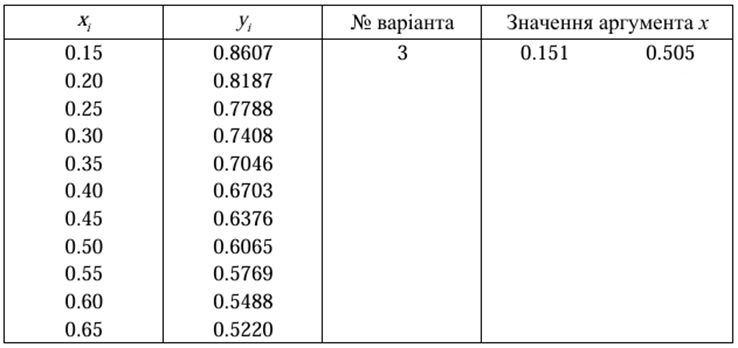

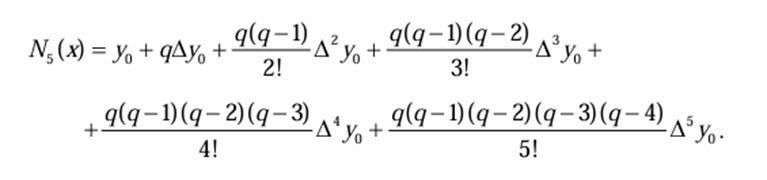

In [16]:
import numpy as np
from math import factorial

# задані точки
x = np.array([0.15, 0.2, 0.25, 0.3, 0.35, 0.4])  # задаємо x генератором списків
y = np.array([0.8607, 0.8187, 0.7788, 0.7408, 0.7046, 0.6703])

print('x =', x)
print('y =', y)

# Перша інтерполяційна формула Ньютона (інтерполяція вперед)
def newton_forward_interpolation(x, y, x0):
    n = len(x)
    h = x[1] - x[0]  # Крок між вузлами (він має бути однаковим)

    # Обчислення кінцевих різниць
    delta_y = np.zeros((n, n))
    delta_y[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):
            delta_y[i, j] = delta_y[i + 1, j - 1] - delta_y[i, j - 1]

    # Обчислення значення q
    q = (x0 - x[0]) / h

    # Використання формули Ньютона для інтерполяції вперед
    ans = delta_y[0, 0]
    q_prod = 1

    for i in range(1, n):
        q_prod *= (q - i + 1)
        ans += (q_prod * delta_y[0, i]) / factorial(i)

    return ans


# Обчислюємо значення функції в точці x = 0.151
x1 = 0.151
y1 = newton_forward_interpolation(x, y, x1)

print(f"f({x1}) = {y1}")

x = [0.15 0.2  0.25 0.3  0.35 0.4 ]
y = [0.8607 0.8187 0.7788 0.7408 0.7046 0.6703]
f(0.151) = 0.8598380280993361


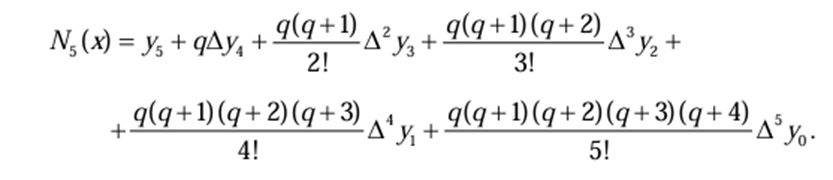

In [17]:
import numpy as np
from math import factorial


# Друга інтерполяційна формула Ньютона (інтерполяція назад)
def newton_backward_interpolation(x, y, x0):
    n = len(x)
    h = x[1] - x[0]  # Крок між вузлами (він має бути однаковим)

    # Обчислення кінцевих різниць
    delta_y = np.zeros((n, n))
    delta_y[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):
            delta_y[i, j] = delta_y[i + 1, j - 1] - delta_y[i, j - 1]

    # Обчислення значення q
    q = (x0 - x[-1]) / h

    # Використання формули Ньютона для інтерполяції назад
    ans = delta_y[-1, 0]  # Починаємо з y_n
    q_prod = 1

    for i in range(1, n):
        q_prod *= (q + i - 1)  # q*(q+1)*(q+2)*...*(q+i-1)
        ans += (q_prod * delta_y[n - i - 1, i]) / factorial(i)

    return ans


# Обчислюємо значення функції в точці x = 0.505
x2 = 0.505
y2 = newton_backward_interpolation(x, y, x2)

print(f"f({x2}) = {y2}")

f(0.505) = 0.6067256816749962
